# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [21]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

### Step 1. Load the data

In [22]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"
df = pd.read_csv(url)
df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [23]:
X = df[['Experience Years']]  
y = df['Salary']            

### Step 2.b print the type of each

In [24]:
print('Type of X:', type(X))
print('Type of y:', type(y))

Type of X: <class 'pandas.core.frame.DataFrame'>
Type of y: <class 'pandas.core.series.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [25]:
print('Target dtype:', y.dtype)
print('The target (Salary) is NUMERICAL (continuous values).')
print('Therefore, this is a REGRESSION task.')

Target dtype: int64
The target (Salary) is NUMERICAL (continuous values).
Therefore, this is a REGRESSION task.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [26]:
print('X shape (samples, features):', X.shape)
print('y shape (samples,)         :', y.shape)
print(f'\nNumber of samples : {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')

X shape (samples, features): (40, 1)
y shape (samples,)         : (40,)

Number of samples : 40
Number of features: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [27]:
summary = df.agg(['min', 'max', 'median', 'mean', 'std'])
print(summary)

        Experience Years         Salary
min             1.100000   37731.000000
max            10.500000  122391.000000
median          4.600000   64472.500000
mean            5.152500   74743.625000
std             2.663715   25947.122885


### Step 5. Plot the feature vs the target

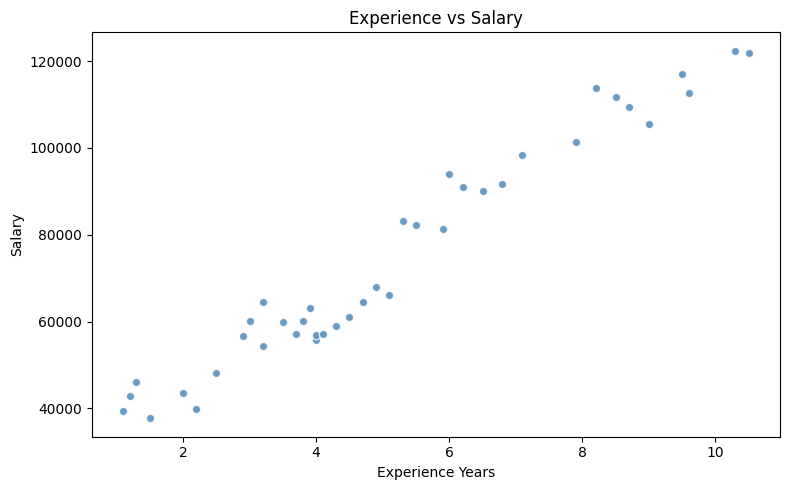

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', edgecolors='white', alpha=0.8)
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [29]:
correlation = df['Experience Years'].corr(df['Salary'])
print(f'Pearson correlation: {correlation:.4f}')
print()
print('The relationship is INCREASING (positive correlation).')
print('As experience years increase, salary tends to increase as well.')

Pearson correlation: 0.9777

The relationship is INCREASING (positive correlation).
As experience years increase, salary tends to increase as well.


### Step 7. Initialize a regression model

In [30]:
model = LinearRegression()
print('Model initialized:', model)

Model initialized: LinearRegression()


### Step 8. Split the dataset into train and test sets

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training samples:', X_train.shape[0])
print('Test samples    :', X_test.shape[0])

Training samples: 32
Test samples    : 8


### Step 9.a Train the model on the training set

In [32]:
model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [33]:
slope     = model.coef_[0]
intercept = model.intercept_
print(f'Slope (coef_)    : {slope:.2f}')
print(f'Intercept        : {intercept:.2f}')
print(f'\nEquation: Salary = {slope:.2f} * ExperienceYears + {intercept:.2f}')

Slope (coef_)    : 9408.03
Intercept        : 26716.25

Equation: Salary = 9408.03 * ExperienceYears + 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [34]:
salary_2yrs = model.predict([[2]])[0]
print(f'Predicted salary for 2 years of experience: ${salary_2yrs:,.2f}')       

Predicted salary for 2 years of experience: $45,532.31


c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [35]:
# 6 months = 0.5 years
salary_increase_6m = slope * 0.5
print(f'Salary increase for 6 months (0.5 years) of experience: ${salary_increase_6m:,.2f}')

Salary increase for 6 months (0.5 years) of experience: $4,704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [36]:
salary_zero_exp = model.predict([[0]])[0]
print(f'Estimated salary with 0 years of experience: ${salary_zero_exp:,.2f}')
print(f'(This equals the intercept: ${intercept:,.2f})')

Estimated salary with 0 years of experience: $26,716.25
(This equals the intercept: $26,716.25)


c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 10. Evaluate the model on the test set

In [37]:
y_pred = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

print(f'MSE  (Mean Squared Error)     : {mse:,.2f}')
print(f'RMSE (Root Mean Squared Error): {rmse:,.2f}')
print(f'R²   (Coefficient of Det.)    : {r2:.4f}')
print(f'\nInterpretation: The model explains {r2*100:.1f}% of the variance in salary.')

MSE  (Mean Squared Error)     : 48,077,731.17
RMSE (Root Mean Squared Error): 6,933.81
R²   (Coefficient of Det.)    : 0.9069

Interpretation: The model explains 90.7% of the variance in salary.


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [38]:
sample_X = X_test.sample(3, random_state=1)
sample_y = y_test.loc[sample_X.index]
sample_pred = model.predict(sample_X)

comparison = pd.DataFrame({
    'Experience Years': sample_X['Experience Years'].values,
    'True Salary'     : sample_y.values,
    'Predicted Salary': sample_pred.round(2),
    'Difference'      : (sample_y.values - sample_pred).round(2)
})
print(comparison.to_string(index=False))

 Experience Years  True Salary  Predicted Salary  Difference
              6.2        91000          85046.04     5953.96
              4.0        55794          64348.38    -8554.38
              4.0        56957          64348.38    -7391.38


### Step 12. Plot the data and the regression line

c:\Users\DynaBook\Downloads\AAI\student\W3\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


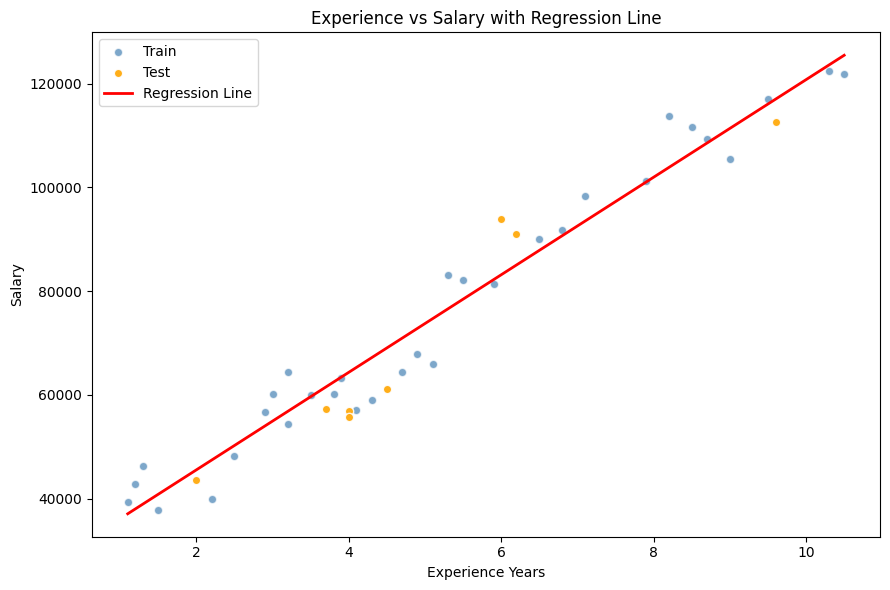

In [39]:
import numpy as np

x_line = np.linspace(X['Experience Years'].min(), X['Experience Years'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, color='steelblue', label='Train', alpha=0.7, edgecolors='white')
plt.scatter(X_test,  y_test,  color='orange',    label='Test',  alpha=0.9, edgecolors='white')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()